In [1]:
!pip install folium geopandas


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sys
!{sys.executable} -m pip install folium geopandas


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\pc\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [124]:
orders_geo   = pd.read_csv('olist_augmented_data/orders_augmented.csv')
payments_geo = pd.read_csv('olist_augmented_data/order_payments_augmented.csv')
customers    = pd.read_csv('olist_processed_data/customers_cleaned.csv')
geolocation  = pd.read_csv('olist_processed_data/geolocation_cleaned.csv')

orders_geo = orders_geo[orders_geo['order_status'] == 'delivered']

df_geo = orders_geo.merge(customers, on='customer_id', how='left')
df_geo = df_geo.merge(payments_geo[['order_id', 'payment_value']], on='order_id', how='left')

print(f"Orders loaded    : {len(orders_geo)}")
print(f"Merged dataset   : {df_geo.shape}")
print(f"\nColumns available: {df_geo.columns.tolist()}")
print(f"\nSample:")
print(df_geo.head(3))

Orders loaded    : 135312
Merged dataset   : (139591, 15)

Columns available: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_approved', 'Unnamed: 0', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'payment_value']

Sample:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
2  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
2    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   

  order_delivered_carrier_date order_deli

State Level Analysis

STATE LEVEL ANALYSIS:
customer_state  total_revenue  total_orders  total_customers  avg_order_value
            SP    15094277.36         56679            40856       266.311639
            RJ     5040331.06         17500            12509       288.018918
            MG     4433053.39         15886            11438       279.054097
            RS     2095440.40          7469             5374       280.551667
            PR     1950290.01          6930             4961       281.427130
            SC     1429621.24          4965             3574       287.939827
            BA     1352017.68          4592             3293       294.428937
            DF      842140.96          2944             2101       286.053315
            GO      798939.61          2756             1981       289.891005
            ES      716180.54          2720             1999       263.301669
            PE      639740.72          2182             1609       293.190064
            CE      582355.32          182

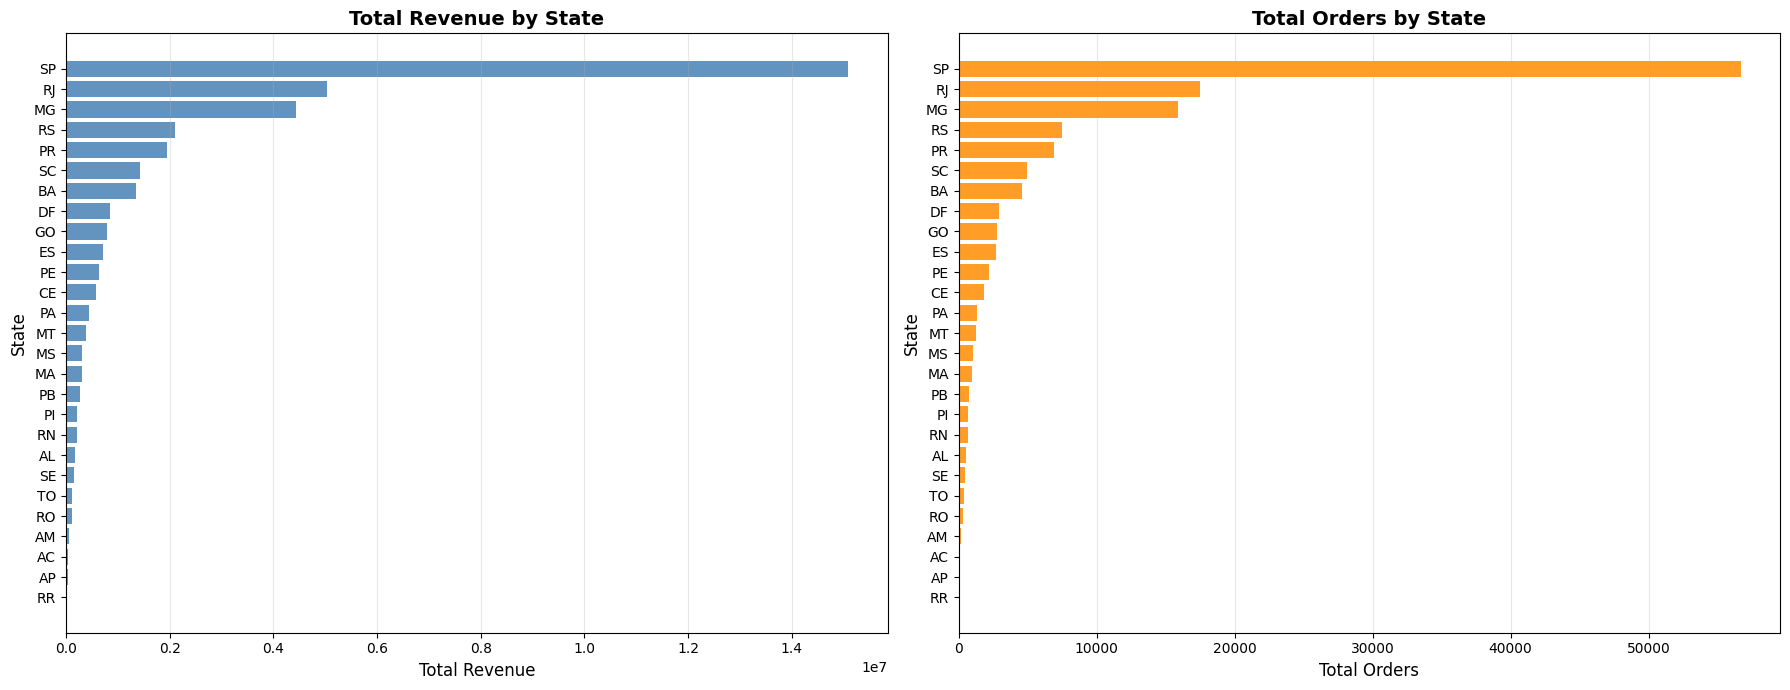

In [125]:

state_analysis = df_geo.groupby('customer_state').agg(
    total_revenue = ('payment_value', 'sum'),
    total_orders  = ('order_id',      'nunique'),
    total_customers = ('customer_id', 'nunique')
).reset_index()

state_analysis['avg_order_value'] = state_analysis['total_revenue'] / state_analysis['total_orders']
state_analysis = state_analysis.sort_values('total_revenue', ascending=False).reset_index(drop=True)

print("STATE LEVEL ANALYSIS:")
print(state_analysis.to_string(index=False))


fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].barh(state_analysis['customer_state'], state_analysis['total_revenue'],
             color='steelblue', alpha=0.85)
axes[0].set_title('Total Revenue by State', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Revenue', fontsize=12)
axes[0].set_ylabel('State', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(state_analysis['customer_state'], state_analysis['total_orders'],
             color='darkorange', alpha=0.85)
axes[1].set_title('Total Orders by State', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Orders', fontsize=12)
axes[1].set_ylabel('State', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

City Level Analysis

Total unique cities: 4284

Top 20 Cities by Revenue:
        customer_city customer_state  total_revenue  total_orders  total_customers  avg_order_value
            sao paulo             SP     5620845.44         21117            15195       266.176324
       rio de janeiro             RJ     2695194.80          9329             6688       288.905006
       belo horizonte             MG     1022015.24          3776             2719       270.660816
             brasilia             DF      840136.81          2933             2092       286.442826
             curitiba             PR      589941.85          2090             1497       282.268828
             campinas             SP      520796.06          1943             1423       268.037087
         porto alegre             RS      512145.55          1860             1348       275.347070
             salvador             BA      476750.64          1673             1201       284.967507
            guarulhos             SP      39783

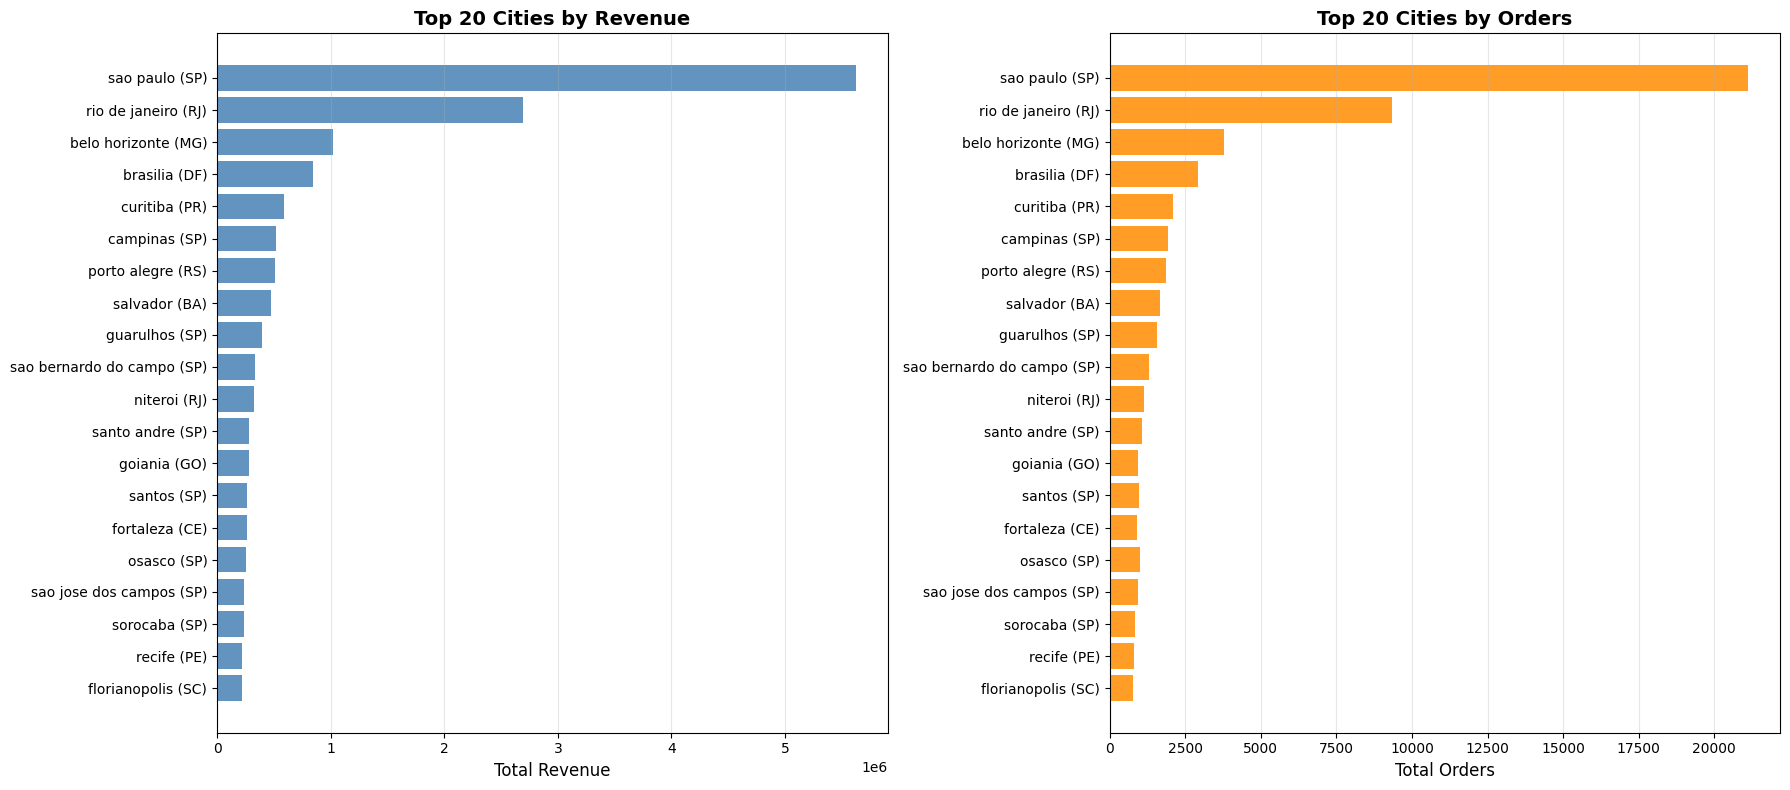

In [126]:

city_analysis = df_geo.groupby(['customer_city', 'customer_state']).agg(
    total_revenue   = ('payment_value', 'sum'),
    total_orders    = ('order_id',      'nunique'),
    total_customers = ('customer_id',   'nunique')
).reset_index()

city_analysis['avg_order_value'] = city_analysis['total_revenue'] / city_analysis['total_orders']
city_analysis = city_analysis.sort_values('total_revenue', ascending=False).reset_index(drop=True)

print(f"Total unique cities: {len(city_analysis)}")
print("\nTop 20 Cities by Revenue:")
print(city_analysis.head(20).to_string(index=False))


top20_cities = city_analysis.head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

axes[0].barh(top20_cities['customer_city'] + ' (' + top20_cities['customer_state'] + ')',
             top20_cities['total_revenue'], color='steelblue', alpha=0.85)
axes[0].set_title('Top 20 Cities by Revenue', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Revenue', fontsize=12)
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)


axes[1].barh(top20_cities['customer_city'] + ' (' + top20_cities['customer_state'] + ')',
             top20_cities['total_orders'], color='darkorange', alpha=0.85)
axes[1].set_title('Top 20 Cities by Orders', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Orders', fontsize=12)
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Prepare Coordinates for DBSCAN

In [127]:
geo_avg = geolocation.groupby('geolocation_zip_code_prefix').agg(
    lat = ('geolocation_lat', 'mean'),
    lng = ('geolocation_lng', 'mean')
).reset_index()


customers['zip_prefix'] = customers['customer_zip_code_prefix'].astype(str).str[:5].astype(int)
geo_avg['zip_prefix']   = geo_avg['geolocation_zip_code_prefix'].astype(int)

customers_geo = customers.merge(geo_avg[['zip_prefix', 'lat', 'lng']], on='zip_prefix', how='left')


customer_revenue = df_geo.groupby('customer_id').agg(
    total_revenue = ('payment_value', 'sum'),
    total_orders  = ('order_id',      'nunique')
).reset_index()

customers_geo = customers_geo.merge(customer_revenue, on='customer_id', how='left')
customers_geo = customers_geo.dropna(subset=['lat', 'lng'])


customers_geo = customers_geo[
    (customers_geo['lat'].between(-35, 5)) &
    (customers_geo['lng'].between(-75, -30))
]

print(f"Customers with coordinates: {len(customers_geo)}")
print(f"\nSample:")
print(customers_geo[['customer_id', 'customer_state', 'lat', 'lng', 'total_revenue']].head())

Customers with coordinates: 99154

Sample:
                        customer_id customer_state        lat        lng  \
0  06b8999e2fba1a1fbc88172c00ba8bc7             SP -20.498489 -47.396929   
1  18955e83d337fd6b2def6b18a428ac77             SP -23.727992 -46.542848   
2  4e7b3e00288586ebd08712fdd0374a03             SP -23.531642 -46.656289   
3  b2b6027bc5c5109e529d4dc6358b12c3             SP -23.499702 -46.185233   
4  4f2d8ab171c80ec8364f7c12e35b23ad             SP -22.975100 -47.142925   

   total_revenue  
0         498.18  
1         335.48  
2         157.73  
3         173.30  
4         252.25  


DBSCAN Clustering

In [128]:
from sklearn.cluster import DBSCAN

sample_size = min(10000, len(customers_geo))
customers_geo_sample = customers_geo.sample(n=sample_size, random_state=42).reset_index(drop=True)

print(f"Using {sample_size} sampled points for DBSCAN (out of {len(customers_geo)} total)")

coords = customers_geo_sample[['lat', 'lng']].values

scaler_geo = StandardScaler()
coords_scaled = scaler_geo.fit_transform(coords)

dbscan = DBSCAN(eps=0.3, min_samples=50, n_jobs=-1)
customers_geo_sample['cluster'] = dbscan.fit_predict(coords_scaled)

n_clusters = len(set(customers_geo_sample['cluster'])) - (1 if -1 in customers_geo_sample['cluster'].values else 0)
n_noise    = (customers_geo_sample['cluster'] == -1).sum()

print(f"\nDBSCAN Results:")
print(f"  Clusters found : {n_clusters}")
print(f"  Noise points   : {n_noise} ({n_noise/sample_size*100:.1f}%)")
print(f"\nCluster distribution:")
print(customers_geo_sample['cluster'].value_counts().sort_index())

cluster_summary = customers_geo_sample[customers_geo_sample['cluster'] != -1].groupby('cluster').agg(
    customers     = ('customer_id',   'count'),
    avg_revenue   = ('total_revenue', 'mean'),
    total_revenue = ('total_revenue', 'sum'),
    avg_lat       = ('lat',           'mean'),
    avg_lng       = ('lng',           'mean')
).reset_index()

print(f"\nCluster Summary:")
print(cluster_summary.to_string(index=False))

Using 10000 sampled points for DBSCAN (out of 99154 total)

DBSCAN Results:
  Clusters found : 4
  Noise points   : 497 (5.0%)

Cluster distribution:
cluster
-1     497
 0    8690
 1     603
 2     122
 3      88
Name: count, dtype: int64

Cluster Summary:
 cluster  customers  avg_revenue  total_revenue    avg_lat    avg_lng
       0       8690   385.166518     3282774.23 -22.906034 -46.640520
       1        603   425.684991      249877.09 -10.423490 -37.209318
       2        122   453.600583       54432.07  -4.132945 -38.621455
       3         88   463.768409       40811.62  -1.680058 -48.523037


Scatter Plot of Clusters

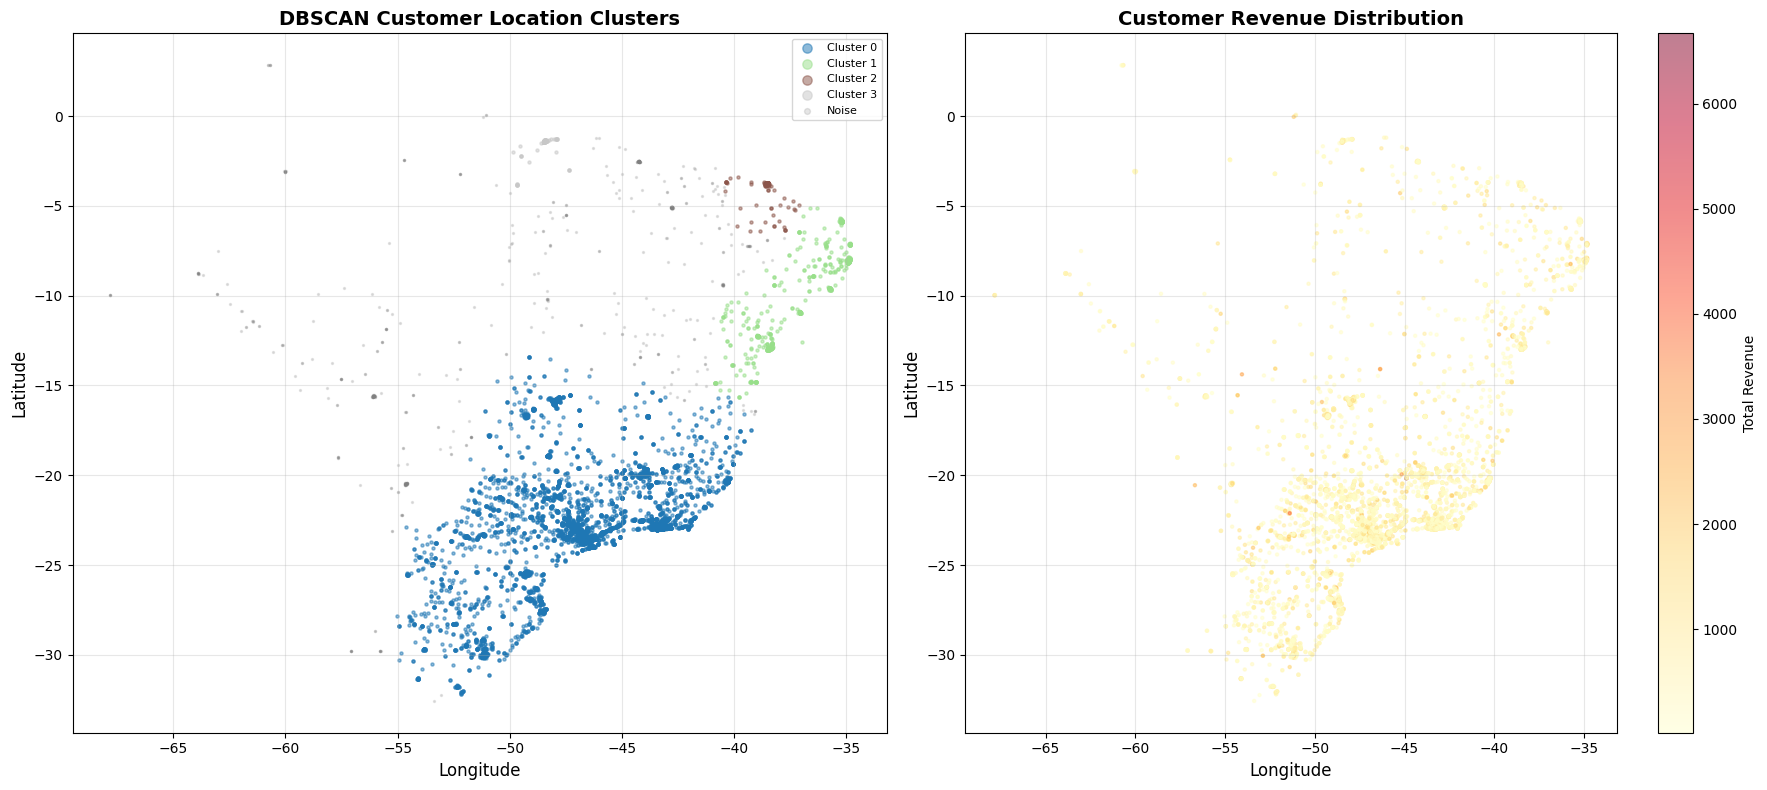

In [129]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

clustered = customers_geo_sample[customers_geo_sample['cluster'] != -1]
noise_pts = customers_geo_sample[customers_geo_sample['cluster'] == -1]
n_colors  = customers_geo_sample['cluster'].nunique()
palette   = plt.cm.tab20(np.linspace(0, 1, n_colors))

for i, cluster_id in enumerate(sorted(clustered['cluster'].unique())):
    mask = clustered['cluster'] == cluster_id
    axes[0].scatter(clustered[mask]['lng'], clustered[mask]['lat'],
                    s=5, alpha=0.5, color=palette[i], label=f'Cluster {cluster_id}')

axes[0].scatter(noise_pts['lng'], noise_pts['lat'],
                s=2, alpha=0.2, color='gray', label='Noise')
axes[0].set_title('DBSCAN Customer Location Clusters', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Longitude', fontsize=12)
axes[0].set_ylabel('Latitude', fontsize=12)
axes[0].legend(fontsize=8, markerscale=3)
axes[0].grid(True, alpha=0.3)

sc = axes[1].scatter(customers_geo_sample['lng'], customers_geo_sample['lat'],
                     c=customers_geo_sample['total_revenue'], cmap='YlOrRd',
                     s=5, alpha=0.5)
plt.colorbar(sc, ax=axes[1], label='Total Revenue')
axes[1].set_title('Customer Revenue Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Longitude', fontsize=12)
axes[1].set_ylabel('Latitude', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Interactive Folium Map

In [130]:
import folium
from folium.plugins import HeatMap


m = folium.Map(location=[-15.0, -50.0], zoom_start=4, tiles='CartoDB positron')

heat_data = customers_geo_sample[['lat', 'lng', 'total_revenue']].dropna().values.tolist()
HeatMap(heat_data, radius=8, blur=10, min_opacity=0.4).add_to(m)

for _, row in cluster_summary.iterrows():
    folium.CircleMarker(
        location=[row['avg_lat'], row['avg_lng']],
        radius=10,
        color='blue',
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"""<b>Cluster {int(row['cluster'])}</b><br>
            Customers: {int(row['customers'])}<br>
            Avg Revenue: R${row['avg_revenue']:,.2f}<br>
            Total Revenue: R${row['total_revenue']:,.2f}""",
            max_width=200
        )
    ).add_to(m)

m.save('olist_augmented_data/geospatial_map.html')
print("Interactive map saved: olist_augmented_data/geospatial_map.html")
print("Open this file in your browser to explore the map!")

from IPython.display import IFrame
IFrame('olist_augmented_data/geospatial_map.html', width=900, height=500)

Interactive map saved: olist_augmented_data/geospatial_map.html
Open this file in your browser to explore the map!
